# Sunspot Cycle

Dominant frequency = 0.0916 1/year
Dominant period    = 10.91 years


/tmp/ipykernel_254988/3158899614.py:58: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig("Figures/times.png", dpi=300)
/tmp/ipykernel_254988/3158899614.py:58: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig("Figures/times.png", dpi=300)
/tmp/ipykernel_254988/3158899614.py:58: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig("Figures/times.png", dpi=300)
/tmp/ipykernel_254988/3158899614.py:58: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "bbox_inches_restore" which is no longer supported as of 3.3 and will become an error two minor releases later
  pl

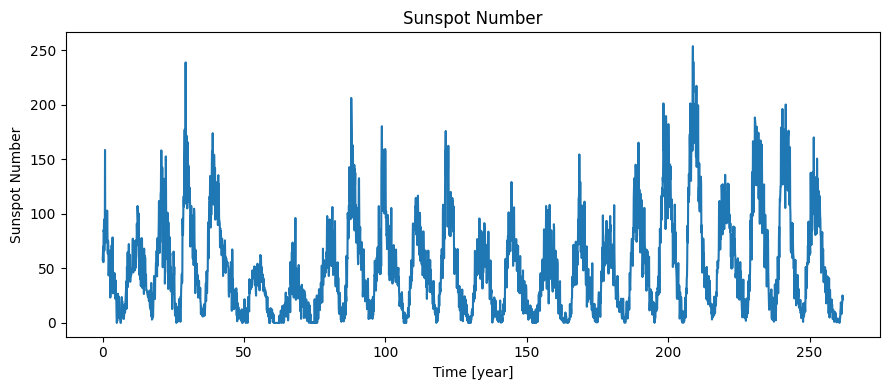

/tmp/ipykernel_254988/3158899614.py:72: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig("Figures/fft.png", dpi=300)
/tmp/ipykernel_254988/3158899614.py:72: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig("Figures/fft.png", dpi=300)
/tmp/ipykernel_254988/3158899614.py:72: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig("Figures/fft.png", dpi=300)
/tmp/ipykernel_254988/3158899614.py:72: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "bbox_inches_restore" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.save

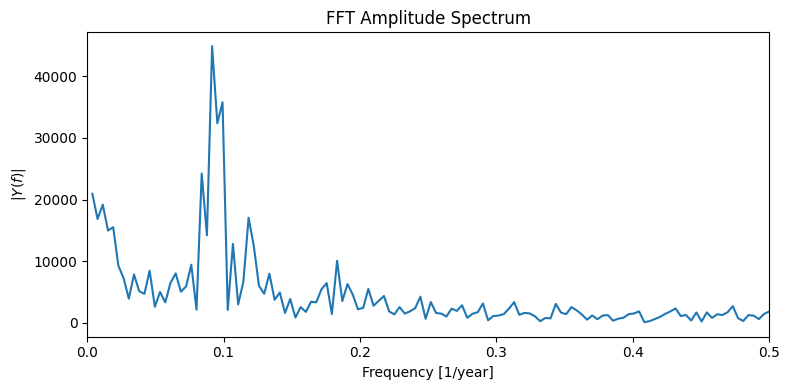

/tmp/ipykernel_254988/3158899614.py:88: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig("Figures/power.png", dpi=300)
/tmp/ipykernel_254988/3158899614.py:88: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig("Figures/power.png", dpi=300)
/tmp/ipykernel_254988/3158899614.py:88: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig("Figures/power.png", dpi=300)
/tmp/ipykernel_254988/3158899614.py:88: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "bbox_inches_restore" which is no longer supported as of 3.3 and will become an error two minor releases later
  pl

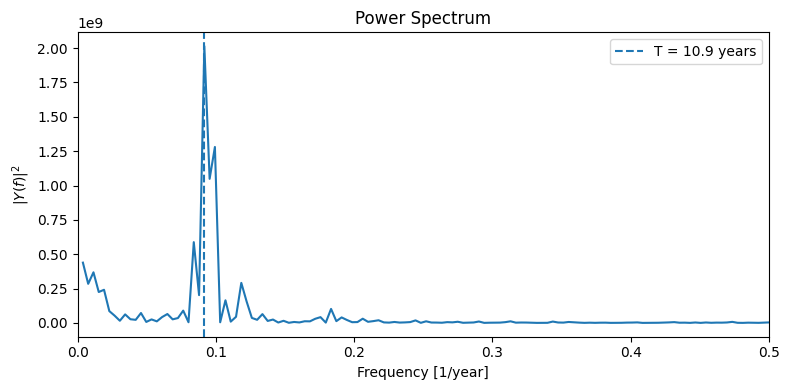

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Download sunspot data
# ============================================================
!wget -q https://websites.umich.edu/~mejn/cp2/data/sunspots.txt

data = np.loadtxt("sunspots.txt")

month = data[:, 0]
sunspot = data[:, 1]

# Time in years
time = month / 12.0


# ============================================================
# 2. FFT of the original data
#    Peng-style basic treatment: no mean subtraction
# ============================================================
N = len(sunspot)
dt = 1.0 / 12.0                    # year

Y = np.fft.fft(sunspot)
freq = np.fft.fftfreq(N, d=dt)

# Positive frequencies, excluding f = 0
mask = freq > 0
freq_pos = freq[mask]
Y_pos = Y[mask]

amplitude = np.abs(Y_pos)
power = np.abs(Y_pos)**2


# ============================================================
# 3. Dominant frequency and period
# ============================================================
peak = np.argmax(power)

f_peak = freq_pos[peak]
T_peak = 1.0 / f_peak

print(f"Dominant frequency = {f_peak:.4f} 1/year")
print(f"Dominant period    = {T_peak:.2f} years")


# ============================================================
# Plot 1: Sunspot time series
# ============================================================
plt.figure(figsize=(9, 4))
plt.plot(time, sunspot)
plt.xlabel("Time [year]")
plt.ylabel("Sunspot Number")
plt.title("Sunspot Number")
plt.tight_layout()
plt.savefig("Figures/times.png", dpi=300)
plt.show()


# ============================================================
# Plot 2: FFT amplitude spectrum
# ============================================================
plt.figure(figsize=(8, 4))
plt.plot(freq_pos, amplitude)
plt.xlim(0, 0.5)
plt.xlabel("Frequency [1/year]")
plt.ylabel(r"$|Y(f)|$")
plt.title("FFT Amplitude Spectrum")
plt.tight_layout()
plt.savefig("Figures/fft.png", dpi=300)
plt.show()


# ============================================================
# Plot 3: Power spectrum
# ============================================================
plt.figure(figsize=(8, 4))
plt.plot(freq_pos, power)
plt.axvline(f_peak, linestyle="--", label=f"T = {T_peak:.1f} years")
plt.xlim(0, 0.5)
plt.xlabel("Frequency [1/year]")
plt.ylabel(r"$|Y(f)|^2$")
plt.title("Power Spectrum")
plt.legend()
plt.tight_layout()
plt.savefig("Figures/power.png", dpi=300)
plt.show()
